# Trading area for depth: a redshift-resolved $n_{\rm eff}$

[`wfd_footprint_example.ipynb`](wfd_footprint_example.ipynb) shrank the footprint and changed
nothing else, so the answer there was unambiguous: less sky is strictly worse.  That is not the
real trade.  A survey with a fixed observing budget that covers **less** sky spends **more**
time per pointing, goes **deeper**, and wins some of the loss back through a higher
$n_{\rm eff}$.

This notebook puts that second term in:

$$A \;\longrightarrow\; t_{\rm exp}\propto 1/A \;\longrightarrow\; \Delta m_{5\sigma}
  \;\longrightarrow\; \frac{n_{\rm eff}^{(b)}(A)}{n_{\rm eff}^{(b),\rm fid}}
  \ \text{counted in a mock, \textbf{per tomographic bin}}
  \;\longrightarrow\; \text{forecast}$$

The count step is measured in the Cardinal gold mock, **locally in redshift**: each source and
lens bin is credited with the fractional count change at *its own* central redshift, not with a
single survey-wide number.  That matters more than it sounds -- the faint end of the counts is
much steeper at $z\sim1.1$ than at $z\sim0.2$, so the high-redshift bins gain two to three
times as much from a given $\Delta m$ as the low-redshift ones.

### Model choices

| step | choice |
|---|---|
| reference footprint | **17,500 deg$^2$**, where the sample is the Y1 gold cut $i < 24.1$ |
| depth scaling | $\Delta m_{5\sigma} = 1.25\,\log_{10}(A_{\rm ref}/A)$ -- background-limited, fixed total survey time |
| source $n_{\rm eff}$ | **per bin**: $f_b = N(i<m_{\rm lim})/N(i<24.1)$ counted in $\|z - z_b\| < 0.05$ |
| lens $n_{\rm eff}$ | **per bin**, same way; the fiducial lens depth is *solved* from $n(0<z<1.2) = 18$ arcmin$^{-2}$ |
| bin centre $z_b$ | source: $\langle z\rangle$ of each truth $n(z)$; lens: the Y1 preset's $z_{\rm eff}$ |
| $\sigma_e$ | held at 0.26 -- all of the depth benefit flows through $n_{\rm eff}$ |
| $n(z)$ *shape* | **held fixed**; only the per-bin normalizations move |

Scanned range **14,000-18,000 deg$^2$**, with **14,800** and **16,500 deg$^2$** called out.

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import qp
import tables_io
from matplotlib import pyplot as plt

from fisherA2Z.fisher_flex import FisherFlex

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

FULL_SKY_DEG2 = 4 * np.pi * (180.0 / np.pi) ** 2

NZDC = "../nzdc_example"
MOCK = "/global/cfs/cdirs/lsst/groups/PZ/data/pz_challenge_cardinal_gold/25/part-0.pq"

AREA_REF = 17500.0                                                # reference footprint, deg^2
AREA_KEY = (14800.0, 16500.0)                                     # comparison points
AREAS = np.union1d(np.arange(14800.0, 18000.1, 250.0), AREA_KEY)   # forecast grid
AREAS_1K = np.arange(14800.0, 18000.1, 1000.0)                    # the n_eff table

M_SRC_FID = 24.1          # LSST Y1 gold cut = the depth *at* AREA_REF
NEFF_LENS_TOTAL = 18.0    # SRD Y1 lens total, arcmin^-2 -- this defines the lens depth
LENS_ZMAX = 1.2           # lens window used to solve for that depth
Z_HALFWIDTH = 0.05        # half-width of the redshift slice the local counts use

SIGMA_E = 0.26
ELL_CUTS = dict(ell_min_cs=300, ell_max_cs=1800)

print(f"reference {AREA_REF:,.0f} deg^2  (f_sky = {AREA_REF / FULL_SKY_DEG2:.4f})")
print(f"forecast grid: {AREAS.size} areas from {AREAS[0]:,.0f} to {AREAS[-1]:,.0f} deg^2")

reference 17,500 deg^2  (f_sky = 0.4242)
forecast grid: 14 areas from 14,800 to 17,800 deg^2


## 1. The mock, and how much sky it actually covers

`pz_challenge_cardinal_gold/25/part-0.pq` is a Cardinal gold catalog carrying `mag_i_lsst` and
true `redshift`.  Its `healpix` column is **nside=32, RING**, and the survey boundary cuts
through most of those pixels -- so the naive "9 pixels $\times$ 3.357 deg$^2$" would
overestimate the area by 50%.

Three pixels are covered *completely*.  Using only those gives an exact area with no boundary
or occupancy estimate, which is what the number densities below rest on.

In [2]:
table = pq.read_table(MOCK, columns=["healpix", "mag_i_lsst", "redshift"])
hpx = table["healpix"].to_numpy()
mag_i = table["mag_i_lsst"].to_numpy().astype(float)
z_mock = table["redshift"].to_numpy().astype(float)

PIX_AREA_DEG2 = FULL_SKY_DEG2 / (12 * 32 * 32)      # nside=32 pixel, 3.3572 deg^2
FULL_PIX = (10177, 10305, 10429)                    # the fully covered pixels

rows = []
for p in np.unique(hpx):
    n = int((hpx == p).sum())
    rows.append({"healpix": p, "N": n,
                 "N / full-pixel area [arcmin^-2]": n / (PIX_AREA_DEG2 * 3600),
                 "complete": p in FULL_PIX})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

keep = np.isin(hpx, FULL_PIX)
mag_i, z_mock = mag_i[keep], z_mock[keep]
order = np.argsort(z_mock)                 # sort by z once; the local counts slice on it
z_mock, mag_i = z_mock[order], mag_i[order]

MOCK_AREA_DEG2 = len(FULL_PIX) * PIX_AREA_DEG2
MOCK_AREA_MIN2 = MOCK_AREA_DEG2 * 3600

print(f"\nusing {len(FULL_PIX)} complete pixels: {MOCK_AREA_DEG2:.4f} deg^2, "
      f"{mag_i.size:,} galaxies, {mag_i.size / MOCK_AREA_MIN2:.2f} arcmin^-2 "
      f"to i < {mag_i.max():.1f}")

 healpix      N  N / full-pixel area [arcmin^-2]  complete
    9921 424405                            35.12     False
   10050 400522                            33.14     False
   10177 619347                            51.25      True
   10178 360186                            29.80     False
   10305 589020                            48.74      True
   10306 139776                            11.57     False
   10429 602153                            49.82      True
   10549 422951                            35.00     False
   10665  26631                             2.20     False

using 3 complete pixels: 10.0715 deg^2, 1,810,520 galaxies, 49.94 arcmin^-2 to i < 25.5


## 2. The forecast inputs, and where the bins sit in redshift

Same Cardinal 1yr sample as the first notebook.  What is new here is that we need each bin's
**central redshift**, because that is where its count response will be evaluated:

- source bins: $\langle z\rangle$ of the truth $n(z)$ in each of the 5 tomographic bins;
- lens bins: the $z_{\rm eff}$ of the `FisherFlex` Y1 lens preset, which is a fixed
  $0.3, 0.5, \ldots, 1.1$ grid.

In [3]:
z_grid = np.linspace(0.01, 3.0, 150)

qp_nz = qp.read(f"{NZDC}/nz_challenge_taskset_1_cardinal_nz_samples_1yr_wfd.hdf5")
nz_realization = np.swapaxes(qp_nz.pdf(z_grid).reshape(5, 10, 150), 0, 1)
nz_central = np.mean(qp_nz.pdf(z_grid).reshape(5, 10, 150), axis=1)
nz_true = qp.read(f"{NZDC}/nz_challenge_taskset_1_cardinal_1yr_nz_true_wfd.hdf5").pdf(z_grid)

bhat_table = tables_io.read(f"{NZDC}/nz_challenge_taskset_1_cardinal_1yr_bhat_wfd.hdf5")
counts = np.bincount(bhat_table["bhat_for_wide_data"], minlength=5)[:5]
NEFF_SRC_FID = counts * (3505864 / (107.4295 * 3600)) / 1000000

# the photo-z prior is the scatter of the n(z) estimator (see notebook 1)
PZ_PRIOR_COV = FisherFlex(
    nz_source=nz_central, nz_realizations=nz_realization, z_grid=z_grid,
    neff_source=NEFF_SRC_FID, fsky=AREA_REF / FULL_SKY_DEG2, sigma_e=SIGMA_E,
    mode="cosmic_shear", nz_model="shift_stretch", y1=True, verbose=False,
).pz_prior_cov

# one throwaway 3x2pt instance to read the Y1 lens preset off: its per-bin n_eff split and
# the effective redshift of each lens bin
_lens_ref = FisherFlex(
    nz_source=nz_true, photoz_prior_cov=PZ_PRIOR_COV, z_grid=z_grid,
    neff_source=NEFF_SRC_FID, fsky=AREA_REF / FULL_SKY_DEG2, sigma_e=SIGMA_E,
    mode="3x2pt", nz_model="shift_stretch", y1=True, verbose=False,
)
NEFF_LENS_FID = _lens_ref.neff_lens.copy()
Z_LENS = _lens_ref.z_eff_lens.copy()
Z_SRC = np.trapz(nz_true * z_grid, z_grid, axis=1) / np.trapz(nz_true, z_grid, axis=1)

print(pd.DataFrame({
    "z_src": Z_SRC, "neff_src": NEFF_SRC_FID,
    "z_lens": Z_LENS, "neff_lens": NEFF_LENS_FID,
}, index=pd.Index(range(1, 6), name="bin")).to_string(float_format=lambda v: f"{v:9.4f}"))
print(f"\ntotals: source {NEFF_SRC_FID.sum():.3f}, lens {NEFF_LENS_FID.sum():.3f} arcmin^-2")

        z_src  neff_src    z_lens  neff_lens
bin                                         
1      0.2145    1.7827    0.3000     3.1574
2      0.3934    1.7801    0.5000     4.8915
3      0.5372    1.7159    0.7000     4.3078
4      0.6875    1.9461    0.9000     3.1786
5      0.9132    1.8401    1.1000     2.4648

totals: source 9.065, lens 18.000 arcmin^-2


## 3. Area $\to$ depth $\to$ per-bin $n_{\rm eff}$

At fixed total survey time the exposure per pointing goes as $1/A$, and a background-limited
5$\sigma$ depth as $t^{1/2}$:

$$\Delta m_{5\sigma}(A) = 1.25\,\log_{10}\!\left(\frac{A_{\rm ref}}{A}\right)
  \qquad\text{(about } \pm0.12 \text{ mag over 14,000-18,000 deg}^2\text{)}.$$

### The two depths

The **source** depth is given: $i<24.1$ at the reference area.  The **lens** depth is solved
for, as the magnitude at which the mock delivers the 18 arcmin$^{-2}$ the SRD Y1 lens sample
has over $0<z<1.2$.  One is asserted and the other derived, so their agreeing is a check on
the mock rather than something imposed.

### The per-bin response

For a bin centred at $z_b$, the factor is counted inside a thin redshift slice:

$$f_b(A) = \frac{N\big(i < m_{\rm fid} + \Delta m,\ |z-z_b| < 0.05\big)}
                {N\big(i < m_{\rm fid},\ |z-z_b| < 0.05\big)}$$

Nothing here depends on the slice's absolute area, since it is a ratio -- and the slice width
cancels too, as the stability check below shows.

In [4]:
mag_lens_sorted = np.sort(mag_i[(z_mock > 0) & (z_mock < LENS_ZMAX)])

def n_lens_total(m):
    """Mock number density of 0 < z < 1.2 galaxies brighter than i = m, arcmin^-2."""
    return np.searchsorted(mag_lens_sorted, m) / MOCK_AREA_MIN2

_grid = np.arange(23.0, 25.50, 0.001)
M_LENS_FID = float(_grid[np.argmin(np.abs([n_lens_total(m) for m in _grid]
                                          - np.float64(NEFF_LENS_TOTAL)))])

mag_all_sorted = np.sort(mag_i)
n_src_total = lambda m: np.searchsorted(mag_all_sorted, m) / MOCK_AREA_MIN2

print(f"source: i < {M_SRC_FID:.3f} (given)   -> n = {n_src_total(M_SRC_FID):6.3f} arcmin^-2 (all z)")
print(f"lens:   i < {M_LENS_FID:.3f} (solved) -> n = {n_lens_total(M_LENS_FID):6.3f} arcmin^-2 "
      f"(0 < z < {LENS_ZMAX}), target {NEFF_LENS_TOTAL:.1f}")

source: i < 24.100 (given)   -> n = 19.289 arcmin^-2 (all z)
lens:   i < 24.098 (solved) -> n = 17.998 arcmin^-2 (0 < z < 1.2), target 18.0


In [5]:
_slice_cache = {}

def _slice_mags(z_centre, half_width=Z_HALFWIDTH):
    """Sorted i magnitudes of the mock galaxies within half_width of z_centre."""
    key = (z_centre, half_width)
    if key not in _slice_cache:
        lo, hi = np.searchsorted(z_mock, [z_centre - half_width, z_centre + half_width])
        _slice_cache[key] = np.sort(mag_i[lo:hi])
    return _slice_cache[key]


def local_factor(z_centre, m_fid, delta_m, half_width=Z_HALFWIDTH):
    """Fractional count change at z_centre when the depth moves by delta_m."""
    m = _slice_mags(z_centre, half_width)
    return np.searchsorted(m, m_fid + delta_m) / np.searchsorted(m, m_fid)


def delta_mag(area):
    """5-sigma depth change relative to AREA_REF, magnitudes (positive = deeper)."""
    return 1.25 * np.log10(AREA_REF / np.asarray(area, dtype=float))


def neff_factors(area):
    """Per-bin (source, lens) n_eff scale factors relative to the fiducial footprint."""
    dm = delta_mag(area)
    return (np.array([local_factor(z, M_SRC_FID, dm) for z in Z_SRC]),
            np.array([local_factor(z, M_LENS_FID, dm) for z in Z_LENS]))


# is the answer set by the survey or by the slice width?
dm14 = delta_mag(14000.0)
stab = pd.DataFrame(
    {f"hw={h}": [local_factor(z, M_SRC_FID, dm14, h) for z in Z_SRC]
                + [local_factor(z, M_LENS_FID, dm14, h) for z in Z_LENS]
     for h in (0.03, 0.05, 0.08, 0.12)},
    index=[f"src z={z:.3f}" for z in Z_SRC] + [f"lens z={z:.3f}" for z in Z_LENS],
)
stab.insert(0, "N in slice", [np.searchsorted(_slice_mags(z), M_SRC_FID) for z in Z_SRC]
                             + [np.searchsorted(_slice_mags(z), M_LENS_FID) for z in Z_LENS])
print(f"slice-width stability of f_b at 14,000 deg^2 (delta m = {dm14:+.4f}):\n")
print(stab.to_string(float_format=lambda v: f"{v:8.4f}"))
print(f"\nspread across slice widths: {100 * (stab.iloc[:, 1:].max(axis=1) / stab.iloc[:, 1:].min(axis=1) - 1).max():.2f}% "
      "-- the factor is set by the counts, not by the binning")

slice-width stability of f_b at 14,000 deg^2 (delta m = +0.1211):

              N in slice  hw=0.03  hw=0.05  hw=0.08  hw=0.12
src z=0.214        49853   1.0619   1.0623   1.0621   1.0617
src z=0.393        55629   1.0648   1.0639   1.0631   1.0631
src z=0.537        81952   1.0645   1.0658   1.0652   1.0659
src z=0.688        79255   1.0691   1.0699   1.0705   1.0696
src z=0.913        54577   1.0864   1.0870   1.0872   1.0864
lens z=0.300       71545   1.0607   1.0607   1.0609   1.0619
lens z=0.500       76540   1.0649   1.0648   1.0650   1.0655
lens z=0.700       77440   1.0696   1.0708   1.0707   1.0697
lens z=0.900       54940   1.0841   1.0858   1.0849   1.0844
lens z=1.100       38311   1.1324   1.1340   1.1352   1.1333

spread across slice widths: 0.25% -- the factor is set by the counts, not by the binning


In [6]:
src_tab = pd.DataFrame({f"{a:,.0f}": neff_factors(a)[0] for a in AREAS_1K},
                       index=pd.Index([f"bin {i} (z={z:.3f})" for i, z in enumerate(Z_SRC, 1)],
                                      name="source"))
lens_tab = pd.DataFrame({f"{a:,.0f}": neff_factors(a)[1] for a in AREAS_1K},
                        index=pd.Index([f"bin {i} (z={z:.2f})" for i, z in enumerate(Z_LENS, 1)],
                                       name="lens"))
hdr = pd.DataFrame({f"{a:,.0f}": [delta_mag(a), a / AREA_REF] for a in AREAS_1K},
                   index=pd.Index(["delta m", "A / A_ref"], name="survey"))

print("n_eff factors by bin, 1,000 deg^2 increments:\n")
for t in (hdr, src_tab, lens_tab):
    print(t.to_string(float_format=lambda v: f"{v:8.4f}"), "\n")

print("at the comparison points:")
for a in AREA_KEY:
    fs, fl = neff_factors(a)
    print(f"  {a:,.0f} deg^2 (delta m {delta_mag(a):+.4f}):")
    print(f"      source {np.round(fs, 4)}")
    print(f"      lens   {np.round(fl, 4)}")

n_eff factors by bin, 1,000 deg^2 increments:

            14,800   15,800   16,800   17,800
survey                                       
delta m     0.0910   0.0555   0.0222  -0.0092
A / A_ref   0.8457   0.9029   0.9600   1.0171 

                  14,800   15,800   16,800   17,800
source                                             
bin 1 (z=0.214)   1.0454   1.0280   1.0110   0.9960
bin 2 (z=0.393)   1.0482   1.0287   1.0110   0.9952
bin 3 (z=0.537)   1.0489   1.0296   1.0123   0.9954
bin 4 (z=0.688)   1.0517   1.0308   1.0122   0.9949
bin 5 (z=0.913)   1.0655   1.0386   1.0152   0.9941 

                 14,800   15,800   16,800   17,800
lens                                              
bin 1 (z=0.30)   1.0452   1.0269   1.0107   0.9951
bin 2 (z=0.50)   1.0481   1.0290   1.0118   0.9955
bin 3 (z=0.70)   1.0530   1.0316   1.0122   0.9947
bin 4 (z=0.90)   1.0644   1.0382   1.0149   0.9936
bin 5 (z=1.10)   1.0992   1.0597   1.0232   0.9895 

at the comparison points:
  14,800 deg^2 (

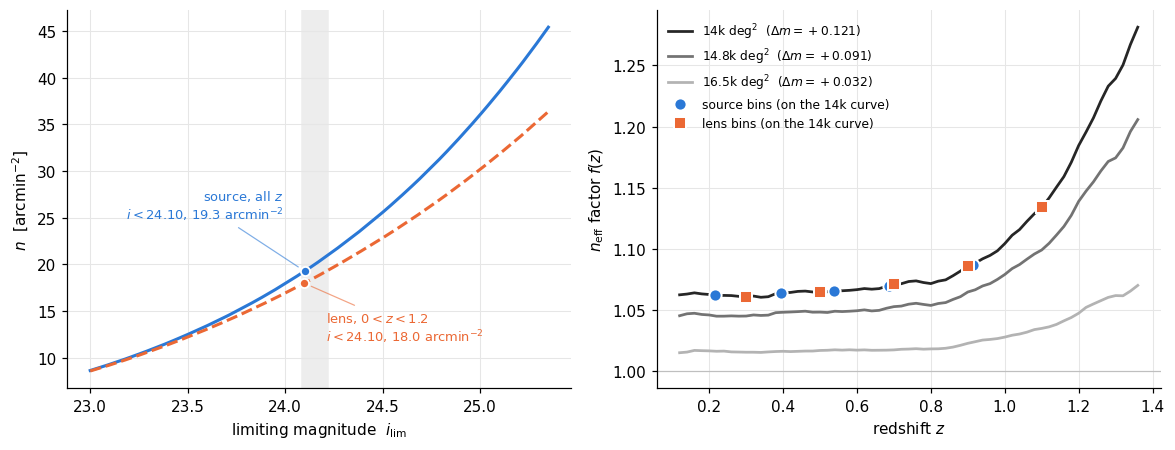

In [13]:
SRC_C, LENS_C = "#2a78d6", "#eb6834"      # validated categorical pair


def dress(ax):
    ax.grid(True, color="0.9", lw=0.7)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.8, 4.2))

# -- left: the cumulative counts the two fiducial depths are read off ------
mgrid = np.arange(23.0, 25.35, 0.01)
axL.plot(mgrid, [n_src_total(m) for m in mgrid], color=SRC_C, lw=2)
axL.plot(mgrid, [n_lens_total(m) for m in mgrid], color=LENS_C, lw=2, ls="--")
for c, m0, n0, lab, dx, dy, ha in (
        (SRC_C, M_SRC_FID, n_src_total(M_SRC_FID), "source, all $z$", -14, 34, "right"),
        (LENS_C, M_LENS_FID, n_lens_total(M_LENS_FID), f"lens, $0<z<{LENS_ZMAX}$", 14, -38, "left")):
    axL.plot(m0, n0, "o", ms=6, color=c, mec="white", mew=1.2, zorder=4)
    axL.annotate(f"{lab}\n$i<{m0:.2f}$, {n0:.1f} arcmin$^{{-2}}$", (m0, n0),
                 xytext=(dx, dy), textcoords="offset points", ha=ha, fontsize=8.5, color=c,
                 arrowprops=dict(arrowstyle="-", color=c, lw=0.8, alpha=0.6,
                                 shrinkA=2, shrinkB=5))
axL.axvspan(M_SRC_FID + delta_mag(18000.0), M_SRC_FID + delta_mag(14000.0),
            color="0.93", zorder=0)
axL.set_xlabel("limiting magnitude  $i_{\\rm lim}$")
axL.set_ylabel("$n$  [arcmin$^{-2}$]")
# axL.set_title("mock counts: where the two fiducial depths come from",
              # fontsize=10, loc="left", color="0.2")
dress(axL)

# -- right: the redshift-resolved response, and where the bins sample it ---
zfine = np.arange(0.12, 1.36, 0.02)
AREA_SHADES = [(14000.0, "0.15"), (AREA_KEY[0], "0.45"), (AREA_KEY[1], "0.70")]
for area, shade in AREA_SHADES:
    dm = delta_mag(area)
    axR.plot(zfine, [local_factor(z, M_SRC_FID, dm) for z in zfine],
             color=shade, lw=1.8, label=f"{area/1e3:g}k deg$^2$  ($\\Delta m={dm:+.3f}$)")
dm14 = delta_mag(14000.0)
axR.plot(Z_SRC, [local_factor(z, M_SRC_FID, dm14) for z in Z_SRC], "o", ms=8,
         color=SRC_C, mec="white", mew=1.3, zorder=5, label="source bins (on the 14k curve)")
axR.plot(Z_LENS, [local_factor(z, M_LENS_FID, dm14) for z in Z_LENS], "s", ms=8,
         color=LENS_C, mec="white", mew=1.3, zorder=5, label="lens bins (on the 14k curve)")
axR.axhline(1.0, color="0.75", lw=0.8)
axR.set_xlabel("redshift $z$")
axR.set_ylabel(r"$n_{\rm eff}$ factor $f(z)$")
# axR.set_title("the same depth buys far more galaxies at high $z$",
              # fontsize=10, loc="left", color="0.2")
axR.legend(fontsize=8, frameon=False, loc="upper left")
dress(axR)

fig.tight_layout()
fig.savefig("wfd_depth_neff_calibration.png", dpi=130)
plt.show()

## 4. The forecast

The source sample, its $n(z)$ shape and the photo-z prior are exactly as in
[`wfd_footprint_example.ipynb`](wfd_footprint_example.ipynb).  The only new thing is that
`neff_source` and `lens_neff` are now **vectors** that depend on the area.

That also costs the shortcut the first notebook used.  There, $n_{\rm eff}$ was fixed, so the
covariance was exactly $\propto 1/f_{\rm sky}$ and one `compute()` covered the whole scan.
Here the *noise* term moves with area too, so the covariance has to be rebuilt -- `compute()`
per area, roughly 7 s for both probes.

In [17]:
neff_factors(area)

(array([1.01628789, 1.01623254, 1.01733942, 1.01717242, 1.02321491]),
 array([1.0152771 , 1.01689313, 1.01726498, 1.02182381, 1.03479418]))

In [8]:
def build(mode, area, depth=True):
    """FisherFlex at one footprint area.

    ``depth=True`` lets the area buy depth and rescales each tomographic bin's n_eff by the
    count change at its own central redshift; ``depth=False`` is the area-only control, with
    n_eff frozen at its fiducial value.
    """
    f_src, f_lens = neff_factors(area) if depth else (np.ones(5), np.ones(5))
    return FisherFlex(
        nz_source=nz_true,
        photoz_prior_cov=PZ_PRIOR_COV,
        z_grid=z_grid,
        neff_source=NEFF_SRC_FID * f_src,     # deeper survey -> more sources, bin by bin
        lens_neff=NEFF_LENS_FID * f_lens,     # ... and more lenses, bin by bin
        fsky=area / FULL_SKY_DEG2,
        sigma_e=SIGMA_E,                      # held fixed by construction
        mode=mode,
        nz_model="shift_stretch",
        y1=True,
        verbose=False,
    )


PROBES = ("cosmic_shear", "3x2pt")
I_REF = int(np.argmin(np.abs(AREAS - AREA_REF)))
metrics = lambda res: (res.s8()[1], res.fom("w_0", "w_a"))

# --- depth-aware scan: n_eff moves, so compute() per area -------------------
scan_depth = {m: {"s8_err": [], "fom": []} for m in PROBES}
for area in AREAS:
    for mode in PROBES:
        s8_err, fom = metrics(build(mode, area).compute(parallel=True).forecast(**ELL_CUTS))
        scan_depth[mode]["s8_err"].append(s8_err)
        scan_depth[mode]["fom"].append(fom)
scan_depth = {m: {k: np.array(v) for k, v in d.items()} for m, d in scan_depth.items()}

# --- area-only control: n_eff fixed, so cov ~ 1/f_sky and one compute() does it all
def forecast_at_area(flex_obj, area):
    saved = flex_obj.cov_blocks
    try:
        flex_obj.cov_blocks = saved * (flex_obj.fsky / (area / FULL_SKY_DEG2))
        return flex_obj.forecast(**ELL_CUTS)
    finally:
        flex_obj.cov_blocks = saved


scan_area = {}
for mode in PROBES:
    ref = build(mode, AREA_REF, depth=False).compute(parallel=True)
    out = [metrics(forecast_at_area(ref, a)) for a in AREAS]
    scan_area[mode] = {"s8_err": np.array([o[0] for o in out]),
                       "fom": np.array([o[1] for o in out])}

for mode in PROBES:
    print(f"{mode:>13} @ {AREA_REF:,.0f} deg^2:  sigma(S_8) = "
          f"{scan_depth[mode]['s8_err'][I_REF]:.5f},  FoM = {scan_depth[mode]['fom'][I_REF]:.2f}")

 cosmic_shear @ 17,500 deg^2:  sigma(S_8) = 0.01470,  FoM = 4.48
        3x2pt @ 17,500 deg^2:  sigma(S_8) = 0.00434,  FoM = 26.73


### The numbers

`with depth` is the trade as modelled; `area only` freezes $n_{\rm eff}$ and reproduces the
first notebook's answer on this grid.  The gap between them is what the extra exposure time
buys back.

In [9]:
at = lambda area, arr: arr[int(np.argmin(np.abs(AREAS - area)))]

rows = []
for area in (14000.0, *AREA_KEY, AREA_REF, 18000.0):
    fs, fl = neff_factors(area)
    row = {"area": area, "A/A_ref": area / AREA_REF, "delta m": delta_mag(area),
           "f_src b1": fs[0], "f_src b5": fs[-1], "f_lens b1": fl[0], "f_lens b5": fl[-1]}
    for mode in PROBES:
        tag = "CS" if mode == "cosmic_shear" else "3x2"
        for key, name in (("s8_err", "s(S8)"), ("fom", "FoM")):
            row[f"{tag} {name} depth"] = at(area, scan_depth[mode][key]) / scan_depth[mode][key][I_REF]
            row[f"{tag} {name} area"] = at(area, scan_area[mode][key]) / scan_area[mode][key][I_REF]
    rows.append(row)

print("everything relative to the 17,500 deg^2 reference:\n")
print(pd.DataFrame(rows).set_index("area").to_string(float_format=lambda v: f"{v:8.4f}"))

everything relative to the 17,500 deg^2 reference:

         A/A_ref  delta m  f_src b1  f_src b5  f_lens b1  f_lens b5  CS s(S8) depth  CS s(S8) area  CS FoM depth  CS FoM area  3x2 s(S8) depth  3x2 s(S8) area  3x2 FoM depth  3x2 FoM area
area                                                                                                                                                                                       
14000.0   0.8000   0.1211    1.0623    1.0870     1.0607     1.1340          1.0376         1.0772        0.9539       0.9070           1.0635          1.0850         0.9074        0.8737
14800.0   0.8457   0.0910    1.0454    1.0655     1.0452     1.0992          1.0376         1.0772        0.9539       0.9070           1.0635          1.0850         0.9074        0.8737
16500.0   0.9429   0.0319    1.0163    1.0232     1.0153     1.0348          1.0134         1.0273        0.9831       0.9649           1.0225          1.0300         0.9655        0.9520
17500.0 

In [10]:
print("fraction of the area-only loss that the extra depth buys back:\n")
print(f"{'area':>8}  {'probe':>13}  {'metric':>9}  {'area only':>11}  {'with depth':>11}  {'recovered':>10}")
for area in (14000.0, *AREA_KEY):
    for mode in PROBES:
        for key, name in (("s8_err", "sigma(S8)"), ("fom", "FoM")):
            loss_a = at(area, scan_area[mode][key]) / scan_area[mode][key][I_REF] - 1.0
            loss_d = at(area, scan_depth[mode][key]) / scan_depth[mode][key][I_REF] - 1.0
            print(f"{area:>8,.0f}  {mode:>13}  {name:>9}  {loss_a:>+11.1%}  {loss_d:>+11.1%}  "
                  f"{1 - loss_d / loss_a:>10.0%}")

fraction of the area-only loss that the extra depth buys back:

    area          probe     metric    area only   with depth   recovered
  14,000   cosmic_shear  sigma(S8)        +7.7%        +3.8%         51%
  14,000   cosmic_shear        FoM        -9.3%        -4.6%         50%
  14,000          3x2pt  sigma(S8)        +8.5%        +6.4%         25%
  14,000          3x2pt        FoM       -12.6%        -9.3%         27%
  14,800   cosmic_shear  sigma(S8)        +7.7%        +3.8%         51%
  14,800   cosmic_shear        FoM        -9.3%        -4.6%         50%
  14,800          3x2pt  sigma(S8)        +8.5%        +6.4%         25%
  14,800          3x2pt        FoM       -12.6%        -9.3%         27%
  16,500   cosmic_shear  sigma(S8)        +2.7%        +1.3%         51%
  16,500   cosmic_shear        FoM        -3.5%        -1.7%         52%
  16,500          3x2pt  sigma(S8)        +3.0%        +2.2%         25%
  16,500          3x2pt        FoM        -4.8%        -3.5%

## 5. The picture

Solid = the area/depth trade; dotted = area only, with $n_{\rm eff}$ frozen.  The shaded wedge
between them is the depth credit.

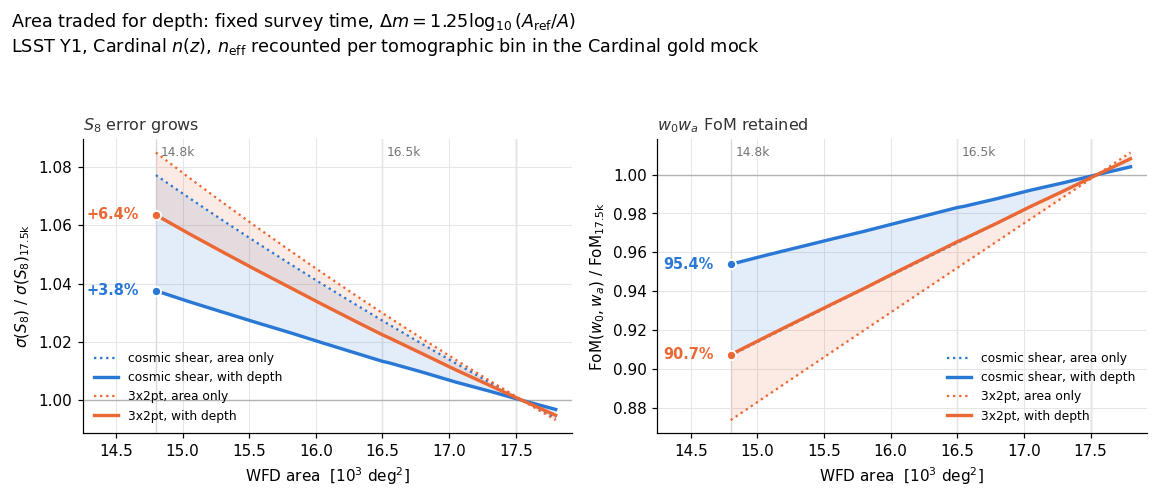

In [11]:
PROBE_STYLE = {
    "cosmic_shear": dict(label="cosmic shear", color="#2a78d6"),
    "3x2pt":        dict(label="3x2pt",        color="#eb6834"),
}
AREA_K = AREAS / 1e3

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.5))
panels = [
    (axes[0], "s8_err", r"$\sigma(S_8)\ /\ \sigma(S_8)_{17.5\mathrm{k}}$",
     r"$S_8$ error grows", "{:+.1%}", "lower left"),
    (axes[1], "fom", r"FoM$(w_0,w_a)\ /\ $FoM$_{17.5\mathrm{k}}$",
     r"$w_0w_a$ FoM retained", "{:.1%}", "lower right"),
]
for ax, key, ylab, title, fmt, legend_loc in panels:
    for mode, st in PROBE_STYLE.items():
        yd = scan_depth[mode][key] / scan_depth[mode][key][I_REF]
        ya = scan_area[mode][key] / scan_area[mode][key][I_REF]
        ax.fill_between(AREA_K, yd, ya, color=st["color"], alpha=0.13, lw=0, zorder=1)
        ax.plot(AREA_K, ya, color=st["color"], lw=1.5, ls=":", zorder=2,
                label=f"{st['label']}, area only")
        ax.plot(AREA_K, yd, color=st["color"], lw=2.2, ls="-", zorder=3,
                label=f"{st['label']}, with depth")
        ax.plot(AREA_K[0], yd[0], "o", ms=6, color=st["color"], mec="white", mew=1.2, zorder=5)
        ax.annotate(fmt.format(yd[0] - 1 if key == "s8_err" else yd[0]),
                    (AREA_K[0], yd[0]), xytext=(-11, 0), textcoords="offset points",
                    va="center", ha="right", fontsize=9.5, color=st["color"], fontweight="bold")
    ax.axhline(1.0, color="0.7", lw=0.9, zorder=2)
    ax.axvline(AREA_REF / 1e3, color="0.75", lw=0.9, zorder=0)
    for a in AREA_KEY:
        ax.axvline(a / 1e3, color="0.85", lw=0.9, zorder=0)
        ax.annotate(f"{a/1e3:g}k", (a / 1e3, ax.get_ylim()[1]), xytext=(3, -11),
                    textcoords="offset points", fontsize=8, color="0.45")
    ax.set_ylabel(ylab)
    ax.set_xlabel(r"WFD area  [$10^3$ deg$^2$]")
    ax.set_title(title, fontsize=10.5, loc="left", color="0.2")
    ax.legend(fontsize=8, frameon=False, loc=legend_loc)
    ax.set_xlim(AREA_K.min() - 0.55, AREA_K.max() + 0.12)
    dress(ax)

fig.suptitle("Area traded for depth: fixed survey time, $\\Delta m = 1.25\\log_{10}(A_{\\rm ref}/A)$\n"
             "LSST Y1, Cardinal $n(z)$, $n_{\\rm eff}$ recounted per tomographic bin in the Cardinal gold mock",
             fontsize=11.5, x=0.012, y=0.995, va="top", ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.945))
fig.savefig("wfd_depth_tradeoff.png", dpi=130)
plt.show()

## 6. Does the per-bin treatment matter?

It is tempting to use one survey-wide factor -- $N(i<m_{\rm lim})/N(i<24.1)$ over the whole
mock -- and apply it to every bin.  That is *wrong in a specific direction*, and worth
quantifying because the error is not small.

The all-redshift sample runs out to $z \approx 2.3$, where the counts are much steeper than
anywhere the five tomographic bins actually live ($\langle z\rangle \le 0.91$).  A global
factor therefore credits the source sample with a depth gain earned by galaxies that are not
in it.

The comparison below reruns just the key areas with the global factor.

In [12]:
f_global = lambda area: n_src_total(M_SRC_FID + delta_mag(area)) / n_src_total(M_SRC_FID)
f_global_lens = lambda area: (n_lens_total(M_LENS_FID + delta_mag(area))
                              / n_lens_total(M_LENS_FID))

print("n_eff factor at 14,000 deg^2:")
fs, fl = neff_factors(14000.0)
print(f"  source, one global factor (all z)      : {f_global(14000.0):.4f}")
print(f"  source, per bin                        : {np.round(fs, 4)}")
print(f"  lens,   one global factor (0 < z < 1.2): {f_global_lens(14000.0):.4f}")
print(f"  lens,   per bin                        : {np.round(fl, 4)}")


def build_global(mode, area):
    return FisherFlex(
        nz_source=nz_true, photoz_prior_cov=PZ_PRIOR_COV, z_grid=z_grid,
        neff_source=NEFF_SRC_FID * f_global(area),
        lens_neff=NEFF_LENS_FID * f_global_lens(area),
        fsky=area / FULL_SKY_DEG2, sigma_e=SIGMA_E, mode=mode,
        nz_model="shift_stretch", y1=True, verbose=False,
    )


cmp_areas = (14000.0, *AREA_KEY, AREA_REF)
glob = {m: {k: [] for k in ("s8_err", "fom")} for m in PROBES}
for area in cmp_areas:
    for mode in PROBES:
        s8_err, fom = metrics(build_global(mode, area).compute(parallel=True).forecast(**ELL_CUTS))
        glob[mode]["s8_err"].append(s8_err)
        glob[mode]["fom"].append(fom)

j_ref = cmp_areas.index(AREA_REF)
print("\nloss recovered by depth, per-bin vs one global factor:\n")
print(f"{'area':>8}  {'probe':>13}  {'metric':>9}  {'per bin':>9}  {'global':>9}")
for j, area in enumerate(cmp_areas[:-1]):
    for mode in PROBES:
        for key, name in (("s8_err", "sigma(S8)"), ("fom", "FoM")):
            loss_a = at(area, scan_area[mode][key]) / scan_area[mode][key][I_REF] - 1.0
            loss_b = at(area, scan_depth[mode][key]) / scan_depth[mode][key][I_REF] - 1.0
            loss_g = glob[mode][key][j] / glob[mode][key][j_ref] - 1.0
            print(f"{area:>8,.0f}  {mode:>13}  {name:>9}  {1 - loss_b / loss_a:>9.0%}  "
                  f"{1 - loss_g / loss_a:>9.0%}")

n_eff factor at 14,000 deg^2:
  source, one global factor (all z)      : 1.0902
  source, per bin                        : [1.0623 1.0639 1.0658 1.0699 1.087 ]
  lens,   one global factor (0 < z < 1.2): 1.0762
  lens,   per bin                        : [1.0607 1.0648 1.0708 1.0858 1.134 ]

loss recovered by depth, per-bin vs one global factor:

    area          probe     metric    per bin     global
  14,000   cosmic_shear  sigma(S8)        51%        49%
  14,000   cosmic_shear        FoM        50%        49%
  14,000          3x2pt  sigma(S8)        25%         7%
  14,000          3x2pt        FoM        27%        10%
  14,800   cosmic_shear  sigma(S8)        51%        62%
  14,800   cosmic_shear        FoM        50%        61%
  14,800          3x2pt  sigma(S8)        25%        31%
  14,800          3x2pt        FoM        27%        32%
  16,500   cosmic_shear  sigma(S8)        51%        63%
  16,500   cosmic_shear        FoM        52%        63%
  16,500          3x2pt  s

## What it says

Depth pays for a real fraction of the sky you give up, and it pays **cosmic shear much better
than 3x2pt**.  At Y1 the shear spectra are strongly shape-noise dominated over
$300<\ell<1800$, so $n_{\rm eff}$ is close to a direct lever on the error bar; 3x2pt leans more
on sample-variance-limited information, which only area can buy.

Resolving $n_{\rm eff}$ by redshift makes the trade look **worse**, not better.  The five
tomographic bins all sit at $\langle z\rangle \le 0.91$, where the counts are shallower than
in the all-redshift sample, so a survey-wide factor over-credits the depth gain by a
meaningful margin.  The per-bin gradient itself is real and steep -- the $z=1.1$ lens bin
gains about twice as much as the $z=0.3$ one -- but it acts on the lens sample, where it helps
3x2pt least.

Going *up* to 18,000 deg$^2$ makes the survey 0.015 mag shallower and costs about 1% of every
bin's $n_{\rm eff}$, so the depth-aware curve gains slightly less from extra area than the
area-only curve does.  The trade cuts both ways.

## Caveats

- **The $n(z)$ *shape* is held fixed.**  Only the per-bin normalizations move.  In reality the
  extra faint galaxies a deeper survey finds sit towards the back of each bin, so each bin's
  $\langle z\rangle$ would creep up and lensing efficiency with it.  Resolving $n_{\rm eff}$ by
  redshift, as done here, captures the *amplitude* part of that effect but not the shape part.
- **$\sigma_e$ is held at 0.26.**  Fainter galaxies have noisier shapes, so a real
  $n_{\rm eff}$ would rise more slowly than raw counts.  This pushes against the depth credit.
- **The depth model is a toy.**  $1.25\log_{10}(A_{\rm ref}/A)$ assumes background-limited
  photometry, a fixed open-shutter budget and no change in the seeing or airmass distribution.
  Rerunning with a $0.625\log_{10}$ variant roughly halves the depth credit and brackets it.
- **The mock is truncated at $i = 25.5$** and covers 10.07 deg$^2$, so it constrains the count
  slope well near $i \sim 24$ but cannot be pushed much deeper.  The thinnest bin slice still
  holds ~38,000 galaxies, so the per-bin factors are not shot-noise limited.
- **Gaussian covariance only**, as in notebook 1 -- no non-Gaussian or super-sample term, so
  the absolute FoMs are optimistic and the area slopes are upper limits.